1. Загрузка и осмотр датасета

TensorFlow version: 2.20.0
Train: (60000, 28, 28), labels: (60000,)
Test: (10000, 28, 28), labels: (10000,)

ПЕРВЫЕ 5 СТРОК ДАТАСЕТА
   label label_name      first_pixels
0      5          5  [0. 0. 0. 0. 0.]
1      0          0  [0. 0. 0. 0. 0.]
2      4          4  [0. 0. 0. 0. 0.]
3      1          1  [0. 0. 0. 0. 0.]
4      9          9  [0. 0. 0. 0. 0.]


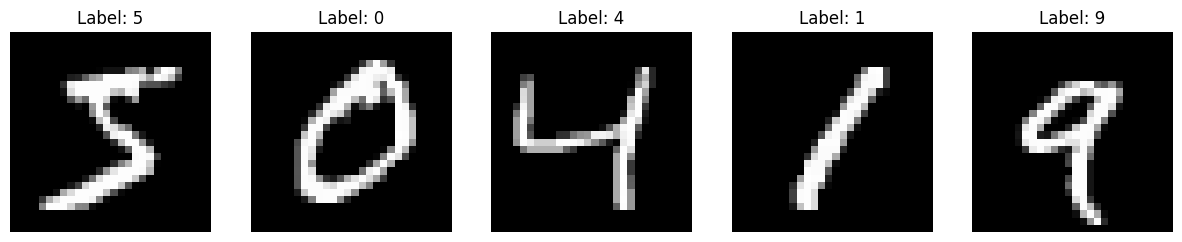

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)

# Загружаем Fashion-MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Train: {x_train.shape}, labels: {y_train.shape}")
print(f"Test: {x_test.shape}, labels: {y_test.shape}")

# Нормализуем к [0,1] и добавляем канал
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# ИСПРАВЛЕННАЯ ТАБЛИЦА ПЕРВЫХ 5 СТРОК
label_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

df_sample = pd.DataFrame({
    'label': y_train[:5],
    'label_name': [label_names[y] for y in y_train[:5]],
    'first_pixels': [str(x_train[i].flatten()[:5]) for i in range(5)]
})

print("\nПЕРВЫЕ 5 СТРОК ДАТАСЕТА")
print(df_sample)

# Визуализация первых 5 изображений
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f'Label: {label_names[y_train[i]]}')
    plt.axis('off')
plt.show()

2. Supervised: Классификация (с учителем)

In [8]:
# Простая CNN для классификации
classifier = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),   # функция скрытого слоя, определяющая черты предметов
    layers.Dense(10, activation='softmax') # на выходе определяет вероятность совпадения
])

classifier.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

classifier.summary()

# Обучаем (3 эпохи)
history_cls = classifier.fit(x_train, y_train,
                            epochs=3, batch_size=256,
                            validation_split=0.2,
                            verbose=1)

# Тест
test_loss, test_acc = classifier.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy (supervised): {test_acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8954 - loss: 0.3836 - val_accuracy: 0.9592 - val_loss: 0.1513
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9654 - loss: 0.1194 - val_accuracy: 0.9739 - val_loss: 0.0941
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9774 - loss: 0.0786 - val_accuracy: 0.9783 - val_loss: 0.0786

Test Accuracy (supervised): 0.9776


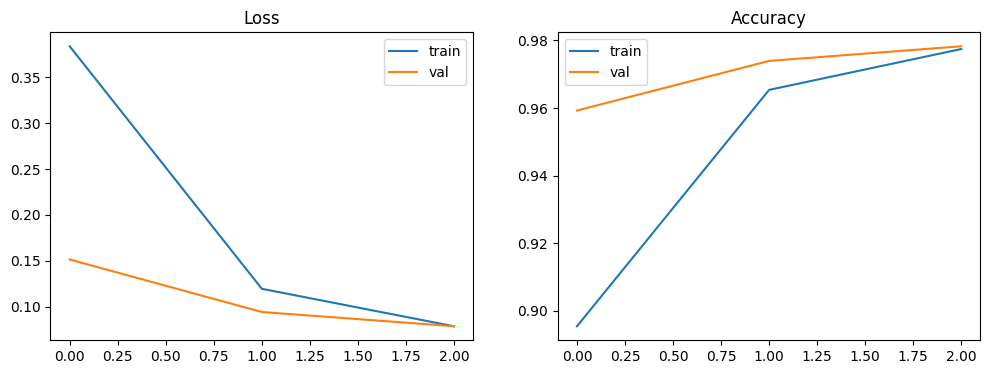

In [12]:
# График обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cls.history['loss'], label='train')
plt.plot(history_cls.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cls.history['accuracy'], label='train')
plt.plot(history_cls.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

3. Unsupervised: Автоэнкодер (без учителя)

In [13]:
# Простой автоэнкодер
autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Encoder (сжимаем)
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),

    # Decoder (восстанавливаем)
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.UpSampling2D(2),
    layers.Conv2D(1, 3, activation='sigmoid', padding='same')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Обучаем (вход = цель, без меток!)
history_ae = autoencoder.fit(x_train, x_train,
                            epochs=3, batch_size=256,
                            validation_data=(x_test, x_test),
                            verbose=1)

# Тест MSE
test_mse = autoencoder.evaluate(x_test, x_test, verbose=0)
print(f"\nTest MSE (unsupervised): {test_mse:.6f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0397 - val_loss: 0.0046
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0035 - val_loss: 0.0026
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0023 - val_loss: 0.0020

Test MSE (unsupervised): 0.001998


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


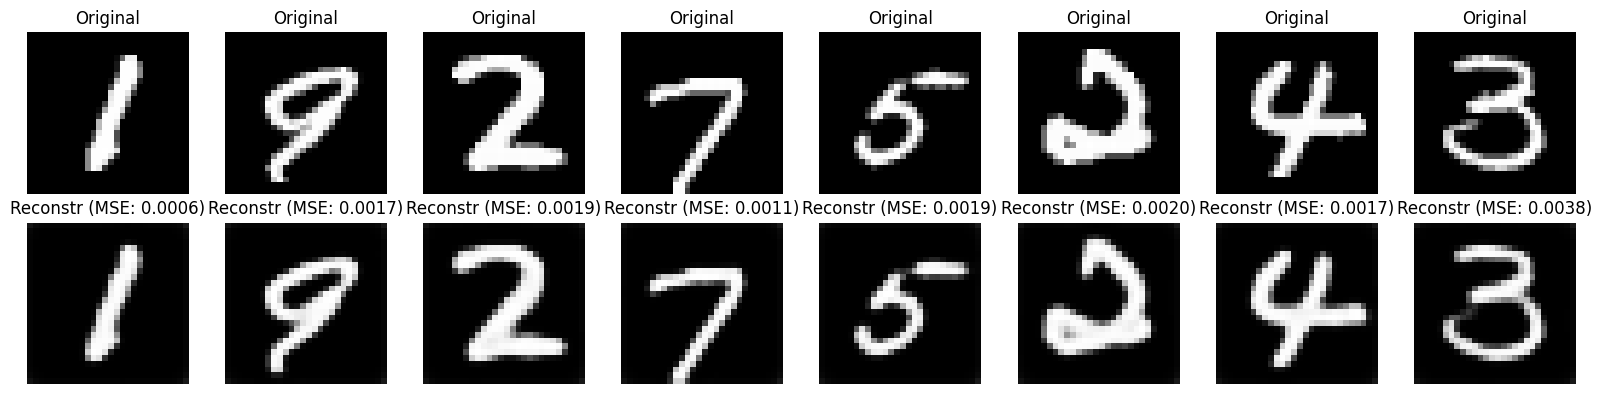

In [11]:
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
n = 8
idx = np.random.choice(len(x_test), n)
x_sample = x_test[idx]
x_recon = autoencoder.predict(x_sample)

plt.figure(figsize=(16, 4))
for i in range(n):
    # Оригинал
    plt.subplot(2, n, i+1)
    plt.imshow(x_sample[i].squeeze(), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Реконструкция
    plt.subplot(2, n, i+n+1)
    plt.imshow(x_recon[i].squeeze(), cmap='gray')
    plt.title(f'Reconstr (MSE: {np.mean((x_sample[i] - x_recon[i])**2):.4f})')
    plt.axis('off')
plt.tight_layout()
plt.show()

4. Выводы

1. **Supervised модель (классификация):**  
   - Accuracy на тесте: 0.9776
   - Модель хорошо обучается, нет переобучения.  
   - Подходит для задач распознавания классов.  

2. **Unsupervised модель (автоэнкодер):**  
   - MSE на тесте: 0.001998  
   - Модель успешно сжимает и восстанавливает изображения.  
   - Простые изображения (типа брюк) восстанавливаются лучше, чем сложные (типа платьев).  
   - Полезно для предобработки данных или обнаружения аномалий.  

**Общий вывод:** Обе модели построены в TensorFlow/Keras, обучены на одном датасете. Supervised даёт интерпретируемые метки, unsupervised — сжатие без меток.